In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# ============================================================
# Load all model results
# ============================================================

layer2a = pd.read_csv("data/layer2a_results.csv")
layer2b = pd.read_csv("data/layer2b_best_result.csv")
lstm = pd.read_csv("data/layer3_lstm_results.csv")
ews = pd.read_csv("data/ews_test_results.csv")

display(layer2a)
display(layer2b)
display(lstm)
display(ews)

,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,Entity Fixed Effects,Observed test (2022-23),346,4.914,2.698,0.173,3.813,3.639,0.174
1,Random Effects,Observed test (2022-23),346,4.816,2.755,0.206,3.813,3.296,0.517
2,Pooled OLS,COVID stress test (2020-21),346,9.095,6.780,-0.191,0.764,2.484,-1.719
3,Entity Fixed Effects,COVID stress test (2020-21),346,8.953,6.646,-0.154,0.764,2.876,-2.112
4,Random Effects,COVID stress test (2020-21),346,9.095,6.780,-0.191,0.764,2.484,-1.719


,Model,Feature_Set,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,Random Forest,Base + all volatility + country history,Observed test (2022-23),346,4.709,2.631,0.241,3.81,4.04,-0.22


,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,LSTM calibrated,Observed test (2022-23),346,5.022,2.829,0.136,3.81,2.95,0.86
1,LSTM calibrated,Year 2022,173,6.184,3.304,0.086,4.51,3.21,1.30
2,LSTM calibrated,Year 2023,173,3.492,2.355,0.217,3.12,2.69,0.42


,Model,Period,N,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Observed test (2022-23),346,0.841,0.878,0.792,0.833,0.923
1,Random Forest,Observed test (2022-23),346,0.827,0.809,0.855,0.831,0.920
2,Extra Trees,Observed test (2022-23),346,0.838,0.791,0.919,0.850,0.930
3,XGBoost,Observed test (2022-23),346,0.835,0.892,0.763,0.822,0.922


In [11]:
# ============================================================
# Regression model comparison
# ============================================================

regression_rows = []

best_2a = (
    layer2a[
        layer2a["Period"] == "Observed test (2022-23)"
    ]
    .sort_values("RMSE")
    .iloc[0]
)

best_2b = layer2b.iloc[0]

lstm_main = (
    lstm[
        lstm["Period"] == "Observed test (2022-23)"
    ]
    .iloc[0]
)

regression_rows.append({
    "Layer": "Layer 2a",
    "Model": best_2a["Model"],
    "Task": "GDP growth regression",
    "RMSE": best_2a["RMSE"],
    "MAE": best_2a["MAE"],
    "R2": best_2a["R2"],
})

regression_rows.append({
    "Layer": "Layer 2b",
    "Model": best_2b["Model"],
    "Task": "GDP growth regression",
    "RMSE": best_2b["RMSE"],
    "MAE": best_2b["MAE"],
    "R2": best_2b["R2"],
})

regression_rows.append({
    "Layer": "Layer 3",
    "Model": "LSTM",
    "Task": "GDP growth sequence regression",
    "RMSE": lstm_main["RMSE"],
    "MAE": lstm_main["MAE"],
    "R2": lstm_main["R2"],
})

regression_comparison = pd.DataFrame(regression_rows)

regression_comparison.to_csv(
    "data/final_regression_model_comparison.csv",
    index=False,
)

display(regression_comparison.sort_values("RMSE"))


,Layer,Model,Task,RMSE,MAE,R2
1,Layer 2b,Random Forest,GDP growth regression,4.709,2.631,0.241
0,Layer 2a,Random Effects,GDP growth regression,4.816,2.755,0.206
2,Layer 3,LSTM,GDP growth sequence regression,5.022,2.829,0.136


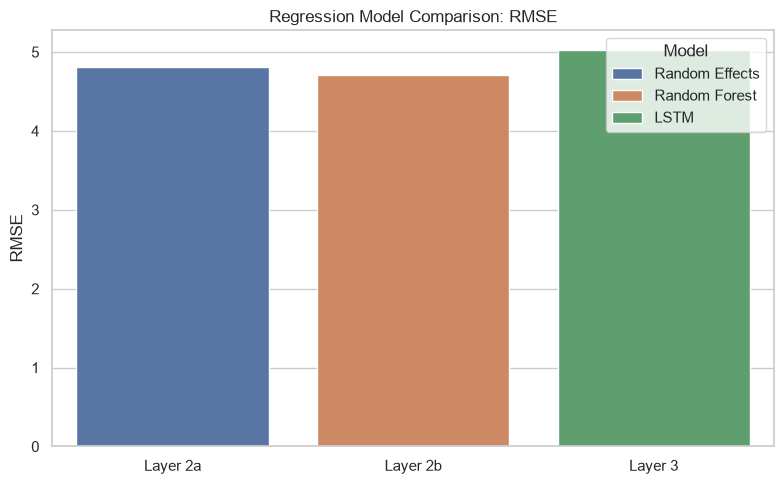

In [12]:
# ============================================================
# Regression comparison plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_comparison,
    x="Layer",
    y="RMSE",
    hue="Model",
)

plt.title("Regression Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xlabel("")
plt.tight_layout()

plt.savefig(
    "final_regression_rmse_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

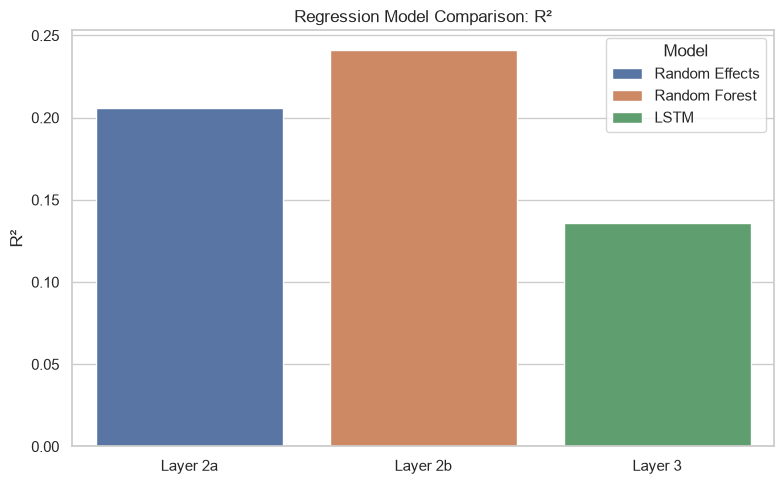

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_comparison,
    x="Layer",
    y="R2",
    hue="Model",
)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Regression Model Comparison: R²")
plt.ylabel("R²")
plt.xlabel("")
plt.tight_layout()

plt.savefig(
    "final_regression_r2_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [14]:
# ============================================================
# EWS classification comparison
# ============================================================

ews_comparison = ews.copy()

ews_comparison.to_csv(
    "data/final_ews_model_comparison.csv",
    index=False,
)

display(
    ews_comparison.sort_values(
        "ROC_AUC",
        ascending=False,
    )
)

,Model,Period,N,Accuracy,Precision,Recall,F1,ROC_AUC
2,Extra Trees,Observed test (2022-23),346,0.838,0.791,0.919,0.850,0.930
0,Logistic Regression,Observed test (2022-23),346,0.841,0.878,0.792,0.833,0.923
3,XGBoost,Observed test (2022-23),346,0.835,0.892,0.763,0.822,0.922
1,Random Forest,Observed test (2022-23),346,0.827,0.809,0.855,0.831,0.920


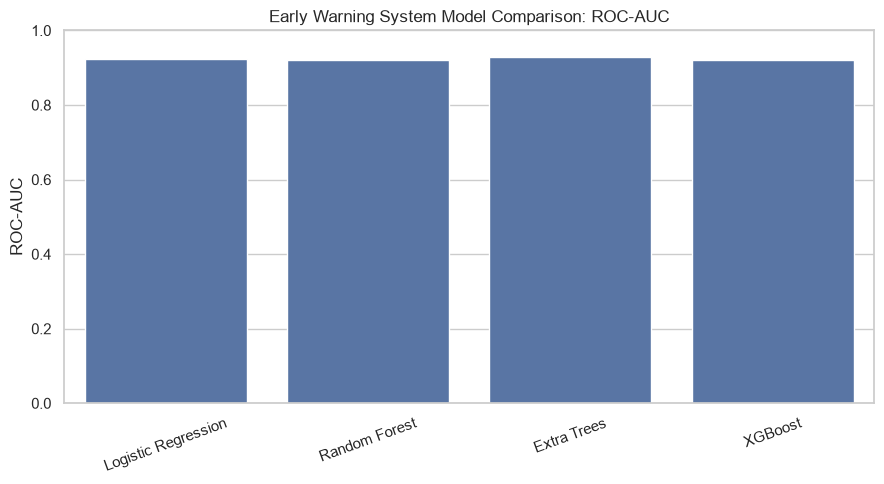

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=ews_comparison,
    x="Model",
    y="ROC_AUC",
)

plt.title("Early Warning System Model Comparison: ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "final_ews_roc_auc_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

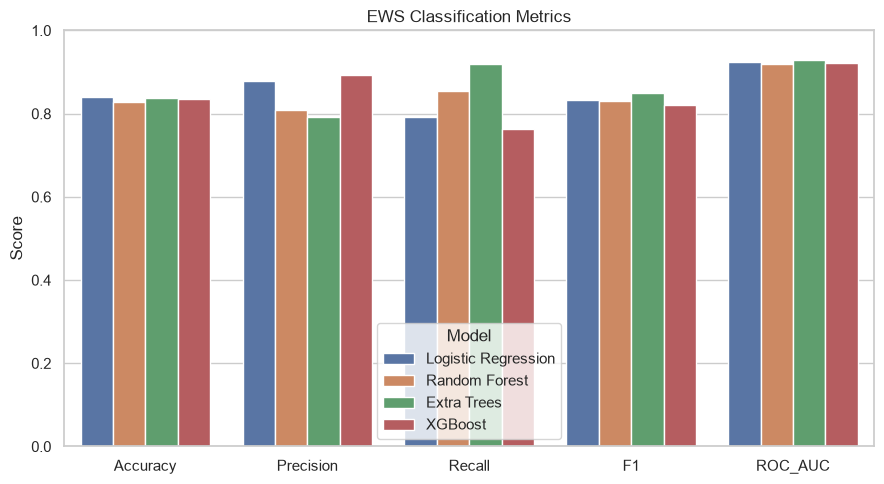

In [16]:
plt.figure(figsize=(9, 5))

ews_melt = ews_comparison.melt(
    id_vars=["Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    var_name="Metric",
    value_name="Score",
)

sns.barplot(
    data=ews_melt,
    x="Metric",
    y="Score",
    hue="Model",
)

plt.title("EWS Classification Metrics")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    "final_ews_metrics_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [17]:
# ============================================================
# Final project summary table
# ============================================================

best_ews = (
    ews_comparison
    .sort_values("ROC_AUC", ascending=False)
    .iloc[0]
)

summary = pd.DataFrame([
    {
        "Component": "Econometric Baseline",
        "Best_Model": best_2a["Model"],
        "Primary_Metric": "RMSE",
        "Score": best_2a["RMSE"],
        "Interpretation": "Interpretable baseline for GDP growth prediction",
    },
    {
        "Component": "Machine Learning Regression",
        "Best_Model": best_2b["Model"],
        "Primary_Metric": "RMSE",
        "Score": best_2b["RMSE"],
        "Interpretation": "Best exact GDP growth forecasting model",
    },
    {
        "Component": "LSTM",
        "Best_Model": "LSTM",
        "Primary_Metric": "RMSE",
        "Score": lstm_main["RMSE"],
        "Interpretation": "Sequence-learning benchmark, weaker than RF",
    },
    {
        "Component": "Early Warning System",
        "Best_Model": best_ews["Model"],
        "Primary_Metric": "ROC-AUC",
        "Score": best_ews["ROC_AUC"],
        "Interpretation": "Best high-instability risk detection layer",
    },
])

summary.to_csv(
    "data/final_project_model_summary.csv",
    index=False,
)

display(summary)

,Component,Best_Model,Primary_Metric,Score,Interpretation
0,Econometric Baseline,Random Effects,RMSE,4.816,Interpretable baseline for GDP growth prediction
1,Machine Learning Regression,Random Forest,RMSE,4.709,Best exact GDP growth forecasting model
2,LSTM,LSTM,RMSE,5.022,"Sequence-learning benchmark, weaker than RF"
3,Early Warning System,Extra Trees,ROC-AUC,0.930,Best high-instability risk detection layer


In [20]:
# ============================================================
# Final 2026-2030 Scenario Forecast Generator
# Random Forest + recursive t+1 forecasting
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import joblib

DATA_DIR = Path("data")
MODEL_DIR = Path("models")
BACKEND_DATA_DIR = Path("08_deployment/backend/data")

BACKEND_DATA_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_YEARS = [2026, 2027, 2028, 2029, 2030]

# ------------------------------------------------------------
# 1. Load data and saved models
# ------------------------------------------------------------

panel = pd.read_csv(DATA_DIR / "03_panel_instability.csv")
panel = panel.sort_values(["COUNTRY", "YEAR"]).copy()

feature_cols = pd.read_csv(
    DATA_DIR / "best_layer2b_feature_cols.csv"
)["Feature"].tolist()

rf_model = joblib.load(MODEL_DIR / "best_layer2b_ml_model.pkl")
ews_model = joblib.load(MODEL_DIR / "ews_extra_trees.pkl")

ews_feature_cols = pd.read_csv(
    DATA_DIR / "ews_feature_importance.csv"
)["Feature"].tolist()

print("Panel:", panel.shape)
print("ML feature count:", len(feature_cols))
print("EWS feature count:", len(ews_feature_cols))

# ------------------------------------------------------------
# 2. Create missing ML features used by best Random Forest model
# ------------------------------------------------------------

panel = panel.sort_values(["COUNTRY", "YEAR"]).copy()

if "Year_Trend" in feature_cols and "Year_Trend" not in panel.columns:
    panel["Year_Trend"] = panel["YEAR"] - panel["YEAR"].min()

if (
    "Country_GDP_Mean_lag1" in feature_cols
    and "Country_GDP_Mean_lag1" not in panel.columns
):
    panel["Country_GDP_Mean_lag1"] = (
        panel.groupby("COUNTRY")["GDP_Growth"]
        .expanding()
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

if (
    "Country_GDP_Std_lag1" in feature_cols
    and "Country_GDP_Std_lag1" not in panel.columns
):
    panel["Country_GDP_Std_lag1"] = (
        panel.groupby("COUNTRY")["GDP_Growth"]
        .expanding()
        .std()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

if (
    "GDP_vs_Country_Mean_lag1" in feature_cols
    and "GDP_vs_Country_Mean_lag1" not in panel.columns
):
    if "Country_GDP_Mean_lag1" not in panel.columns:
        panel["Country_GDP_Mean_lag1"] = (
            panel.groupby("COUNTRY")["GDP_Growth"]
            .expanding()
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )

    panel["GDP_vs_Country_Mean_lag1"] = (
        panel["GDP_Growth_lag1"] - panel["Country_GDP_Mean_lag1"]
    )

missing_ml_features = [
    col for col in feature_cols
    if col not in panel.columns
]

if missing_ml_features:
    print("Creating missing ML features as fallback 0:", missing_ml_features)
    for col in missing_ml_features:
        panel[col] = 0

# ------------------------------------------------------------
# 3. Use 2026 IMF projection-based rows as base
# ------------------------------------------------------------

base_2026 = (
    panel[panel["YEAR"] == 2026]
    .copy()
    .sort_values("COUNTRY")
    .reset_index(drop=True)
)

if base_2026.empty:
    raise ValueError("No 2026 rows found in data/03_panel_instability.csv")

countries = base_2026["COUNTRY"].unique()

ml_medians = (
    panel[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .median(numeric_only=True)
)

available_ews_cols = [
    col for col in ews_feature_cols
    if col in panel.columns
]

ews_medians = (
    panel[available_ews_cols]
    .apply(pd.to_numeric, errors="coerce")
    .median(numeric_only=True)
)

# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def make_numeric_features(df, cols, medians):
    X = df.copy()

    for col in cols:
        if col not in X.columns:
            X[col] = np.nan

    X = X[cols].copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.fillna(medians)
    X = X.fillna(0)

    return X


def risk_label(prob):
    if prob >= 0.60:
        return "High"
    if prob >= 0.30:
        return "Moderate"
    return "Low"


# ------------------------------------------------------------
# 5. Recursive t+1 GDP forecasting
# ------------------------------------------------------------

history = panel.copy()
forecast_rows = []

for year in FORECAST_YEARS:
    print(f"Forecasting {year}...")

    if year == 2026:
        current_year_rows = base_2026.copy()
    else:
        current_year_rows = previous_year_rows.copy()
        current_year_rows["YEAR"] = year

    generated_this_year = []

    for country in countries:
        row = current_year_rows[
            current_year_rows["COUNTRY"] == country
        ].copy()

        if row.empty:
            continue

        row = row.iloc[[0]].copy()

        country_history = (
            history[history["COUNTRY"] == country]
            .sort_values("YEAR")
            .copy()
        )

        # Recursive GDP features
        if len(country_history) >= 1:
            row["GDP_Growth_lag1"] = country_history["GDP_Growth"].iloc[-1]

        if len(country_history) >= 3:
            row["GDP_Growth_rollmean3"] = (
                country_history["GDP_Growth"].tail(3).mean()
            )
            row["GDP_Growth_rollstd3"] = (
                country_history["GDP_Growth"].tail(3).std()
            )

        if len(country_history) >= 5:
            row["GDP_Growth_rollmean5"] = (
                country_history["GDP_Growth"].tail(5).mean()
            )
            row["GDP_Growth_rollstd5"] = (
                country_history["GDP_Growth"].tail(5).std()
            )

        # Country history features
        if "Country_GDP_Mean_lag1" in feature_cols:
            row["Country_GDP_Mean_lag1"] = (
                country_history["GDP_Growth"].mean()
            )

        if "Country_GDP_Std_lag1" in feature_cols:
            row["Country_GDP_Std_lag1"] = (
                country_history["GDP_Growth"].std()
            )

        if "GDP_vs_Country_Mean_lag1" in feature_cols:
            row["GDP_vs_Country_Mean_lag1"] = (
                row["GDP_Growth_lag1"].iloc[0]
                - row["Country_GDP_Mean_lag1"].iloc[0]
            )

        if "Year_Trend" in feature_cols:
            row["Year_Trend"] = row["YEAR"] - panel["YEAR"].min()

        if "Instability_Index" in country_history.columns:
            row["Instability_Index_lag1"] = (
                country_history["Instability_Index"].iloc[-1]
            )

        X_ml = make_numeric_features(
            row,
            feature_cols,
            ml_medians
        )

        predicted_gdp = float(rf_model.predict(X_ml)[0])

        row["Predicted_GDP_Growth"] = predicted_gdp
        row["GDP_Growth"] = predicted_gdp

        generated_this_year.append(row)

    year_df = pd.concat(generated_this_year, ignore_index=True)

    history = pd.concat(
        [history, year_df],
        ignore_index=True
    )

    previous_year_rows = year_df.copy()
    forecast_rows.append(year_df)

future_panel = pd.concat(forecast_rows, ignore_index=True)

# ------------------------------------------------------------
# 6. GDP forecast output
# ------------------------------------------------------------

gdp_forecast = future_panel[
    ["COUNTRY", "YEAR", "Predicted_GDP_Growth"]
].copy()

gdp_forecast["Forecast_Model"] = "Random Forest"

gdp_forecast["Scenario_Type"] = gdp_forecast["YEAR"].apply(
    lambda year: "2026 IMF projection-aligned forecast"
    if year == 2026
    else "Recursive t+1 model extrapolation"
)

gdp_forecast.to_csv(
    DATA_DIR / "layer2b_forecasts_2026_2030.csv",
    index=False
)

print("Saved: data/layer2b_forecasts_2026_2030.csv")

# ------------------------------------------------------------
# 7. EWS forecast output
# ------------------------------------------------------------

ews_input = future_panel.copy()

if "Year_Trend" in ews_feature_cols:
    ews_input["Year_Trend"] = (
        ews_input["YEAR"] - panel["YEAR"].min()
    )

for col in ews_feature_cols:
    if col not in ews_input.columns:
        ews_input[col] = np.nan

X_ews = make_numeric_features(
    ews_input,
    ews_feature_cols,
    ews_medians
)

if hasattr(ews_model, "predict_proba"):
    crisis_prob = ews_model.predict_proba(X_ews)[:, 1]
else:
    crisis_prob = ews_model.predict(X_ews)

ews_forecast = ews_input[["COUNTRY", "YEAR"]].copy()
ews_forecast["Best_EWS_Model"] = "Extra Trees"
ews_forecast["Crisis_Probability"] = crisis_prob
ews_forecast["Risk_Level"] = ews_forecast[
    "Crisis_Probability"
].apply(risk_label)
ews_forecast["Early_Warning_Flag"] = (
    ews_forecast["Crisis_Probability"] >= 0.60
).astype(int)

ews_forecast.to_csv(
    DATA_DIR / "final_ews_2026_2030.csv",
    index=False
)

print("Saved: data/final_ews_2026_2030.csv")

# ------------------------------------------------------------
# 8. Combined frontend file
# ------------------------------------------------------------

combined = gdp_forecast.merge(
    ews_forecast[
        [
            "COUNTRY",
            "YEAR",
            "Crisis_Probability",
            "Risk_Level",
            "Early_Warning_Flag",
        ]
    ],
    on=["COUNTRY", "YEAR"],
    how="left",
)

imf_source = pd.read_csv(
    DATA_DIR / "ews_vs_imf_projection_comparison_2024_2026.csv"
)

imf_2026 = (
    imf_source[imf_source["YEAR"] == 2026][
        ["COUNTRY", "YEAR", "GDP_Growth"]
    ]
    .rename(columns={"GDP_Growth": "IMF_GDP_Growth"})
)

combined = combined.merge(
    imf_2026,
    on=["COUNTRY", "YEAR"],
    how="left",
)

combined["Prediction_Error"] = (
    combined["IMF_GDP_Growth"]
    - combined["Predicted_GDP_Growth"]
)

combined["Scenario_Type"] = combined["YEAR"].apply(
    lambda year: "2026 IMF projection comparison year"
    if year == 2026
    else "2027-2030 recursive t+1 model extrapolation"
)

combined.to_csv(
    DATA_DIR / "scenario_forecasts_2026_2030.csv",
    index=False,
)

print("Saved: data/scenario_forecasts_2026_2030.csv")

# ------------------------------------------------------------
# 9. Top 20 high-risk and low-risk outputs
# ------------------------------------------------------------

top_risk = (
    combined.sort_values(
        "Crisis_Probability",
        ascending=False
    )
    .head(20)
)

low_risk = (
    combined.sort_values(
        "Crisis_Probability",
        ascending=True
    )
    .head(20)
)

top_risk.to_csv(
    DATA_DIR / "ews_top20_high_risk_2026_2030.csv",
    index=False,
)

low_risk.to_csv(
    DATA_DIR / "ews_top20_low_risk_2026_2030.csv",
    index=False,
)

print("Saved top 20 risk files.")

# ------------------------------------------------------------
# 10. Copy files to backend deployment folder
# ------------------------------------------------------------

files_to_copy = [
    "layer2b_forecasts_2026_2030.csv",
    "final_ews_2026_2030.csv",
    "scenario_forecasts_2026_2030.csv",
    "ews_top20_high_risk_2026_2030.csv",
    "ews_top20_low_risk_2026_2030.csv",
]

for filename in files_to_copy:
    src = DATA_DIR / filename
    dst = BACKEND_DATA_DIR / filename
    pd.read_csv(src).to_csv(dst, index=False)
    print("Copied:", dst)

print("\nAll 2026-2030 forecast files generated successfully.")

print("\nPreview:")
display(combined.head(10))

Panel: (5157, 116)
ML feature count: 28
EWS feature count: 28
Forecasting 2026...


c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarnin

Forecasting 2027...


c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarnin

Forecasting 2028...


...

c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarnin

Saved: data/layer2b_forecasts_2026_2030.csv


c:\Users\Ananya Manna\OneDrive\Desktop\FINAL PROJECT\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(


Saved: data/final_ews_2026_2030.csv
Saved: data/scenario_forecasts_2026_2030.csv
Saved top 20 risk files.
Copied: 08_deployment\backend\data\layer2b_forecasts_2026_2030.csv
Copied: 08_deployment\backend\data\final_ews_2026_2030.csv
Copied: 08_deployment\backend\data\scenario_forecasts_2026_2030.csv
Copied: 08_deployment\backend\data\ews_top20_high_risk_2026_2030.csv
Copied: 08_deployment\backend\data\ews_top20_low_risk_2026_2030.csv

All 2026-2030 forecast files generated successfully.

Preview:


,COUNTRY,YEAR,Predicted_GDP_Growth,Forecast_Model,Scenario_Type,Crisis_Probability,Risk_Level,Early_Warning_Flag,IMF_GDP_Growth,Prediction_Error
0,Albania,2026,3.309945,Random Forest,2026 IMF projection comparison year,0.152690,Low,0,3.409,0.099055
1,Algeria,2026,4.141893,Random Forest,2026 IMF projection comparison year,0.568069,Moderate,0,3.777,-0.364893
2,Angola,2026,3.025117,Random Forest,2026 IMF projection comparison year,0.164289,Low,0,2.294,-0.731117
3,Argentina,2026,3.512251,Random Forest,2026 IMF projection comparison year,0.309804,Moderate,0,3.500,-0.012251
4,"Armenia, Republic of",2026,4.393129,Random Forest,2026 IMF projection comparison year,0.191786,Low,0,5.300,0.906871
5,Australia,2026,1.835819,Random Forest,2026 IMF projection comparison year,0.197267,Low,0,2.009,0.173181
6,Austria,2026,1.694090,Random Forest,2026 IMF projection comparison year,0.268358,Low,0,0.682,-1.012090
7,"Azerbaijan, Republic of",2026,2.891180,Random Forest,2026 IMF projection comparison year,0.352904,Moderate,0,2.217,-0.674180
8,"Bahamas, The",2026,2.339646,Random Forest,2026 IMF projection comparison year,0.278773,Low,0,2.100,-0.239646
9,"Bahrain, Kingdom of",2026,1.491613,Random Forest,2026 IMF projection comparison year,0.295548,Low,0,-0.499,-1.990613


Year-wise highest crisis probability:


,YEAR,COUNTRY,Crisis_Probability,Risk_Level,Early_Warning_Flag,Predicted_GDP_Growth,Scenario_Type
0,2026,Suriname,0.660866,High,1,3.963223,2026 IMF projection comparison year
1,2027,Guyana,0.660138,High,1,12.713081,2027-2030 recursive t+1 model extrapolation
2,2028,Suriname,0.663478,High,1,4.109482,2027-2030 recursive t+1 model extrapolation
3,2029,Suriname,0.663042,High,1,4.305216,2027-2030 recursive t+1 model extrapolation
4,2030,Suriname,0.663042,High,1,4.184014,2027-2030 recursive t+1 model extrapolation


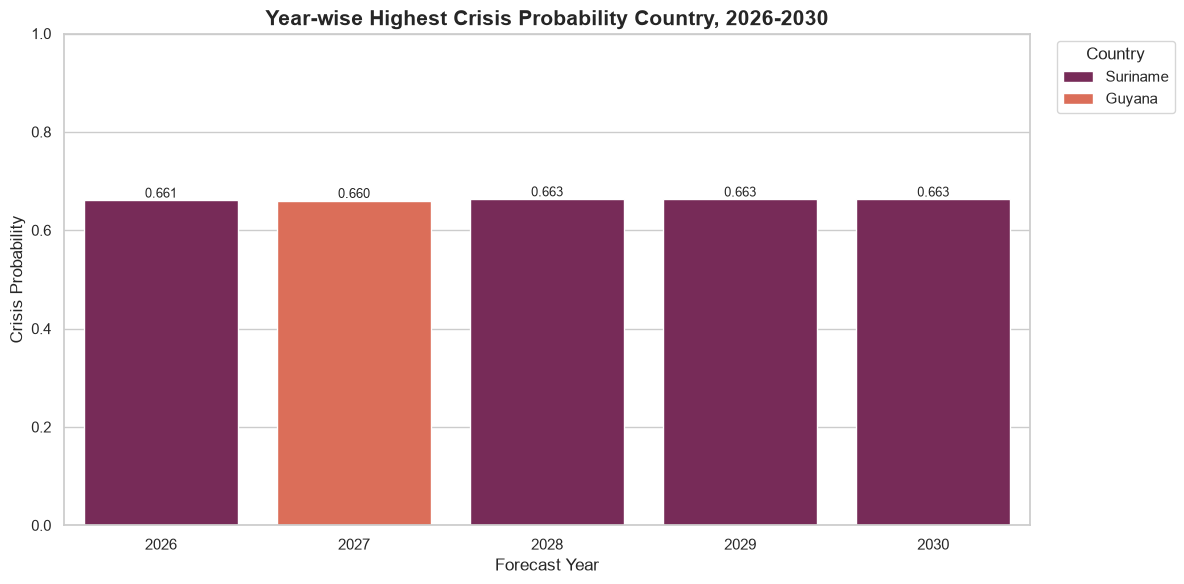

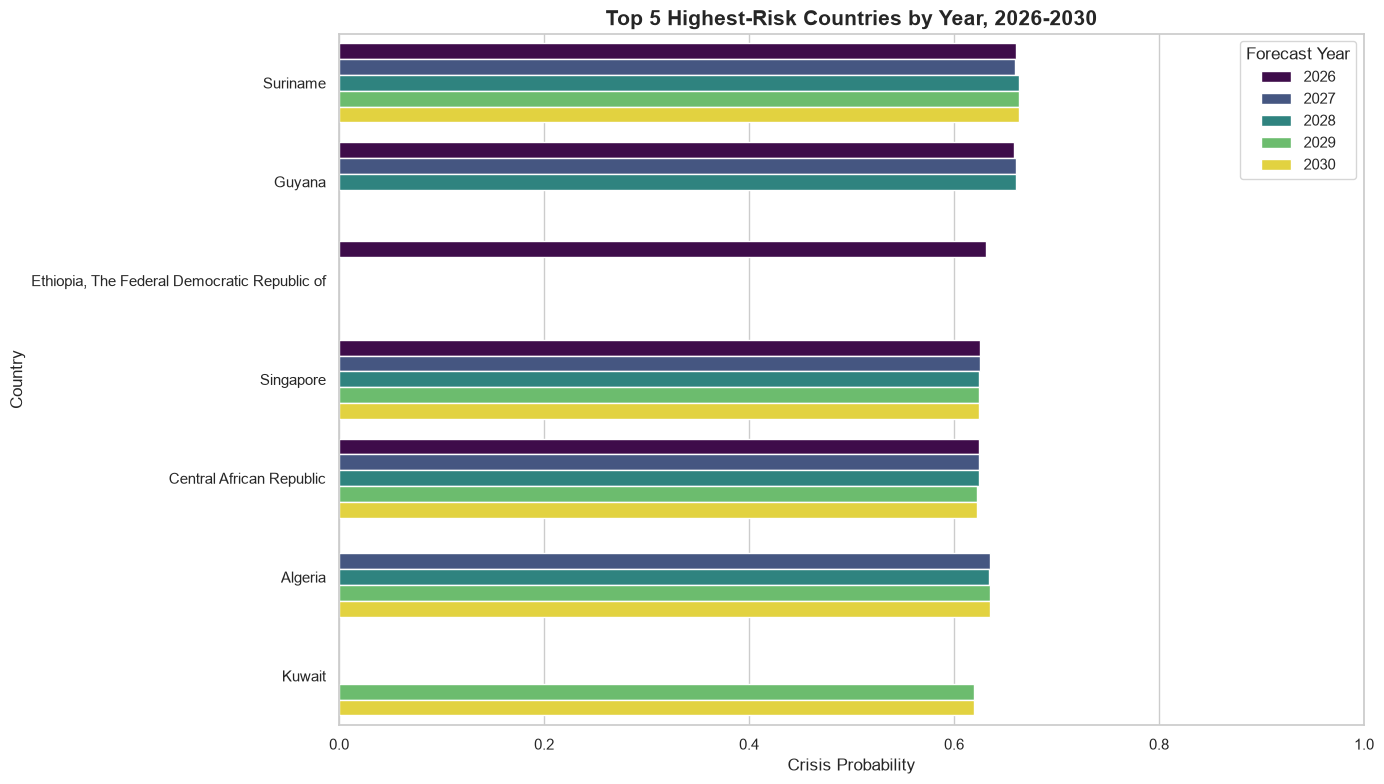

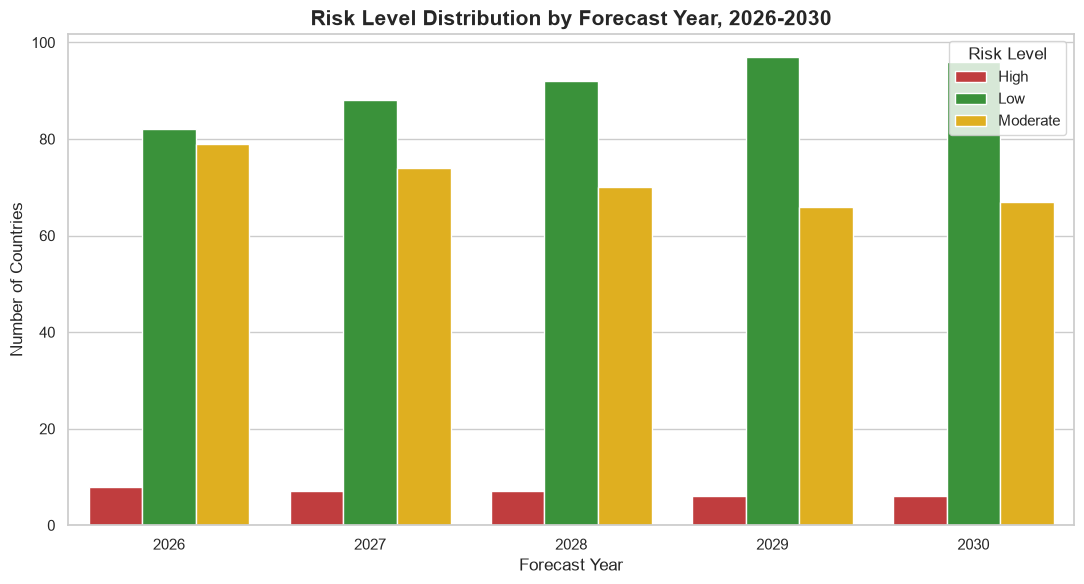

Top 20 prediction errors:


,YEAR,COUNTRY,IMF_GDP_Growth,Predicted_GDP_Growth,Prediction_Error,Absolute_Error,Risk_Level
0,2026,Qatar,-8.646,-0.479609,-8.166391,8.166391,Low
1,2026,"Iran, Islamic Republic of",-6.070,0.788880,-6.858880,6.858880,Low
2,2026,Bolivia,-3.285,1.050039,-4.335039,4.335039,Low
3,2026,Haiti,-1.700,2.384210,-4.084210,4.084210,Low
4,2026,Libya,6.720,3.964018,2.755982,2.755982,Moderate
5,2026,Jamaica,-1.152,1.542513,-2.694513,2.694513,Low
6,2026,Botswana,4.749,2.126255,2.622745,2.622745,High
7,2026,Kuwait,-0.561,1.971115,-2.532115,2.532115,High
8,2026,Guinea,8.677,6.294943,2.382057,2.382057,Moderate
9,2026,"Venezuela, República Bolivariana de",4.043,1.958254,2.084746,2.084746,Moderate


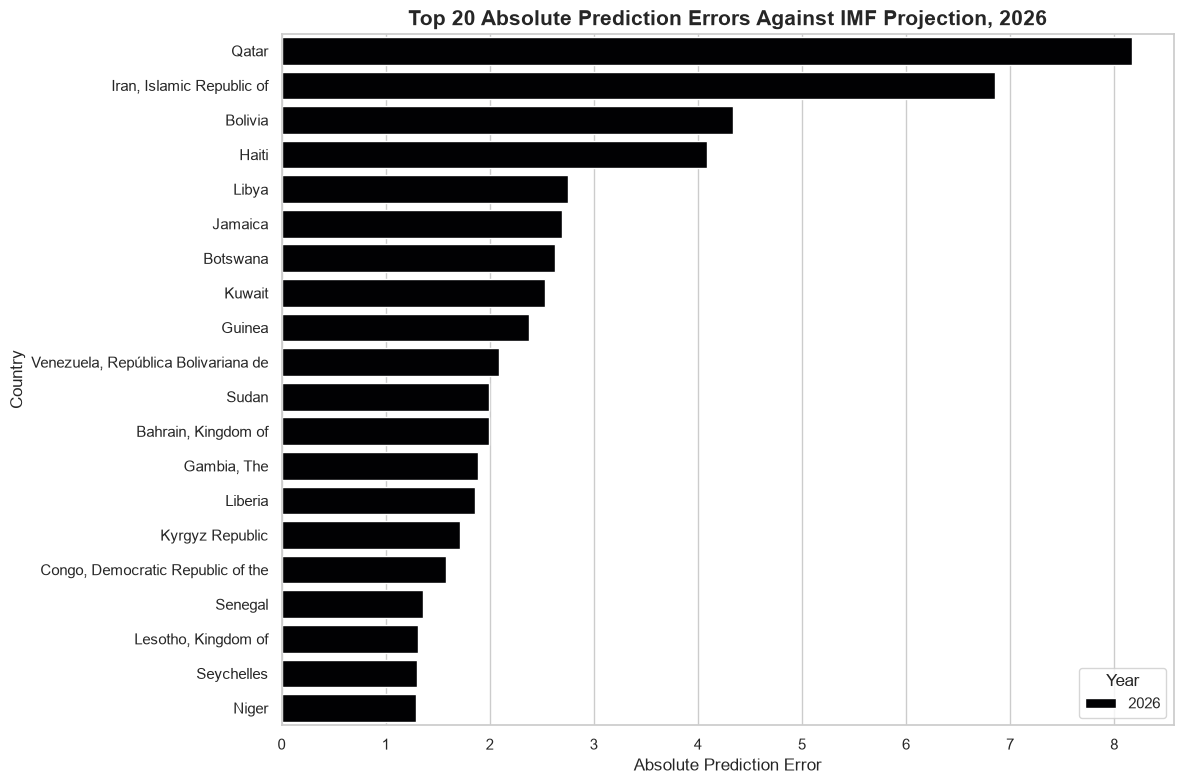

In [21]:
# ============================================================
# Visualizations: Year-wise risk and prediction error
# For 2026-2030 scenario forecasts
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("data")
PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(exist_ok=True)

scenario = pd.read_csv(DATA_DIR / "scenario_forecasts_2026_2030.csv")

# Ensure numeric
scenario["YEAR"] = scenario["YEAR"].astype(int)
scenario["Crisis_Probability"] = pd.to_numeric(
    scenario["Crisis_Probability"],
    errors="coerce"
)
scenario["Predicted_GDP_Growth"] = pd.to_numeric(
    scenario["Predicted_GDP_Growth"],
    errors="coerce"
)

if "Prediction_Error" in scenario.columns:
    scenario["Prediction_Error"] = pd.to_numeric(
        scenario["Prediction_Error"],
        errors="coerce"
    )

# ------------------------------------------------------------
# 1. Year-wise country with maximum crisis probability
# ------------------------------------------------------------

yearwise_top_risk = (
    scenario
    .sort_values(["YEAR", "Crisis_Probability"], ascending=[True, False])
    .groupby("YEAR", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

yearwise_top_risk.to_csv(
    DATA_DIR / "yearwise_highest_crisis_probability_2026_2030.csv",
    index=False
)

print("Year-wise highest crisis probability:")
display(
    yearwise_top_risk[
        [
            "YEAR",
            "COUNTRY",
            "Crisis_Probability",
            "Risk_Level",
            "Early_Warning_Flag",
            "Predicted_GDP_Growth",
            "Scenario_Type",
        ]
    ]
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=yearwise_top_risk,
    x="YEAR",
    y="Crisis_Probability",
    hue="COUNTRY",
    dodge=False,
    palette="rocket"
)

plt.title(
    "Year-wise Highest Crisis Probability Country, 2026-2030",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Forecast Year")
plt.ylabel("Crisis Probability")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9)

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "yearwise_highest_crisis_probability_2026_2030.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 2. Top 5 risky countries per year
# ------------------------------------------------------------

top5_risk_yearwise = (
    scenario
    .sort_values(["YEAR", "Crisis_Probability"], ascending=[True, False])
    .groupby("YEAR")
    .head(5)
    .reset_index(drop=True)
)

top5_risk_yearwise.to_csv(
    DATA_DIR / "yearwise_top5_risk_countries_2026_2030.csv",
    index=False
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top5_risk_yearwise,
    x="Crisis_Probability",
    y="COUNTRY",
    hue="YEAR",
    palette="viridis"
)

plt.title(
    "Top 5 Highest-Risk Countries by Year, 2026-2030",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Crisis Probability")
plt.ylabel("Country")
plt.xlim(0, 1)
plt.legend(title="Forecast Year")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "yearwise_top5_risk_countries_2026_2030.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 3. Risk level distribution by year
# ------------------------------------------------------------

risk_distribution = (
    scenario
    .groupby(["YEAR", "Risk_Level"])
    .size()
    .reset_index(name="Country_Count")
)

risk_distribution.to_csv(
    DATA_DIR / "yearwise_risk_level_distribution_2026_2030.csv",
    index=False
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=risk_distribution,
    x="YEAR",
    y="Country_Count",
    hue="Risk_Level",
    palette={
        "Low": "#2ca02c",
        "Moderate": "#ffbf00",
        "High": "#d62728",
    }
)

plt.title(
    "Risk Level Distribution by Forecast Year, 2026-2030",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Forecast Year")
plt.ylabel("Number of Countries")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "yearwise_risk_level_distribution_2026_2030.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 4. Prediction error visualization
# Only 2026 has IMF projection comparison.
# 2027-2030 have no actual/IMF comparison in this setup.
# ------------------------------------------------------------

error_data = scenario.dropna(subset=["Prediction_Error"]).copy()

if not error_data.empty:
    error_data["Absolute_Error"] = error_data["Prediction_Error"].abs()

    top_error = (
        error_data
        .sort_values("Absolute_Error", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    top_error.to_csv(
        DATA_DIR / "top20_prediction_error_2026.csv",
        index=False
    )

    print("Top 20 prediction errors:")
    display(
        top_error[
            [
                "YEAR",
                "COUNTRY",
                "IMF_GDP_Growth",
                "Predicted_GDP_Growth",
                "Prediction_Error",
                "Absolute_Error",
                "Risk_Level",
            ]
        ]
    )

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=top_error,
        x="Absolute_Error",
        y="COUNTRY",
        hue="YEAR",
        palette="magma"
    )

    plt.title(
        "Top 20 Absolute Prediction Errors Against IMF Projection, 2026",
        fontsize=15,
        fontweight="bold"
    )
    plt.xlabel("Absolute Prediction Error")
    plt.ylabel("Country")
    plt.legend(title="Year")
    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / "top20_prediction_error_2026.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

else:
    print(
        "No prediction error data available. "
        "This is expected for 2027-2030 because IMF comparison values are not available."
    )